In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [3]:
df = pd.read_csv("Bengaluru_House_Data.csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


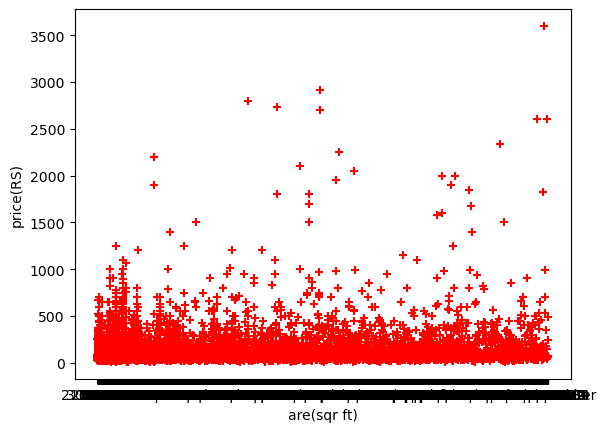

In [5]:
%matplotlib inline
plt.xlabel("are(sqr ft)")
plt.ylabel("price(RS)")

plt.scatter(df.total_sqft, df.price, color='red', marker='+')

In [9]:
# Use pd.to_numeric with errors='coerce' to convert invalid values to NaN
df['total_sqft'] = pd.to_numeric(df['total_sqft'], errors='coerce')
df['total_sqft'].astype(float)
df['total_sqft'] = df['total_sqft'].fillna(df['total_sqft'].mean())
df['total_sqft'] 

0        1056.0
1        2600.0
2        1440.0
3        1521.0
4        1200.0
          ...  
13315    3453.0
13316    3600.0
13317    1141.0
13318    4689.0
13319     550.0
Name: total_sqft, Length: 13320, dtype: float64

In [10]:
reg = linear_model.LinearRegression()
reg.fit(df[['total_sqft']],df.price)

LinearRegression()

In [12]:
reg.predict([[3453]])

C:\Users\Bindra\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([243.98881849])

In [13]:
reg.coef_

array([0.06924087])

In [14]:
reg.intercept_

4.900082020748684

price = m * area + b

In [16]:
pr = float(reg.coef_) * 3453 + float(reg.intercept_)
pr

C:\Users\Bindra\AppData\Local\Temp\ipykernel_12240\3415338318.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pr = float(reg.coef_) * 3453 + float(reg.intercept_)


243.9888184939819

In [18]:
df['pr_price'] = reg.predict(df[['total_sqft']] )
df['pr_price']

0         78.018445
1        184.926353
2        104.606940
3        110.215451
4         87.989130
            ...    
13315    243.988818
13316    254.167227
13317     83.903919
13318    329.570538
13319     42.982562
Name: pr_price, Length: 13320, dtype: float64

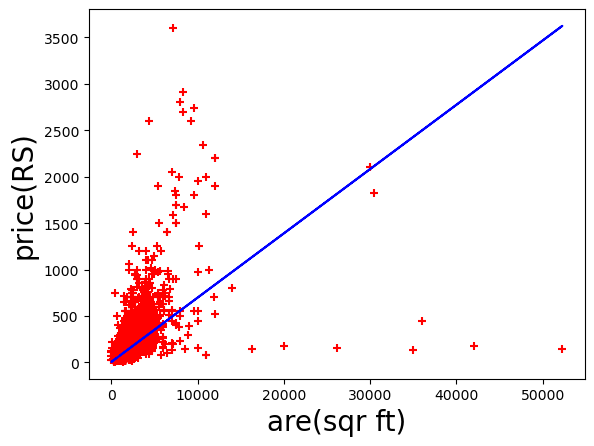

In [19]:
%matplotlib inline
plt.xlabel("are(sqr ft)", fontsize=20)
plt.ylabel("price(RS)", fontsize=20)
plt.scatter(df.total_sqft, df.price, color='red', marker='+')
plt.plot(df.total_sqft,df.pr_price,color='blue')

In [22]:
ca_df = pd.read_csv('canada_per_capita_income.csv')
ca_df.head()

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


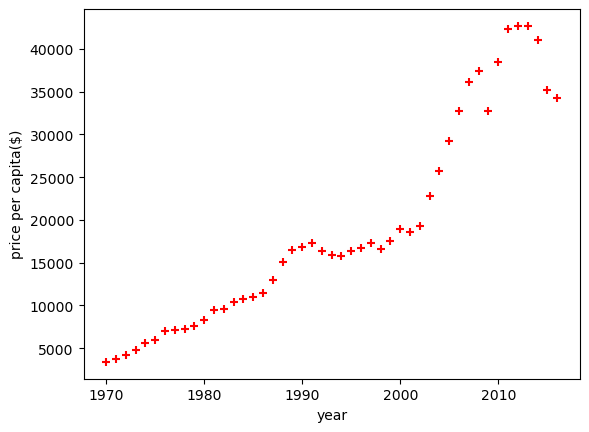

In [23]:
%matplotlib inline
plt.xlabel("year")
plt.ylabel("price per capita($)")

plt.scatter(ca_df.year, ca_df['per capita income (US$)'], color='red', marker='+')

In [25]:
ca_model = linear_model.LinearRegression()
ca_model.fit(ca_df[['year']],ca_df['per capita income (US$)'])

LinearRegression()

In [26]:
ca_model.predict([[1972]])

C:\Users\Bindra\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1522.37048373])

In [27]:
ca_model.predict([[2020]])

C:\Users\Bindra\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([41288.69409442])

In [29]:
d=ca_model.predict([[2020]])
d[0]

C:\Users\Bindra\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


41288.69409441762